In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


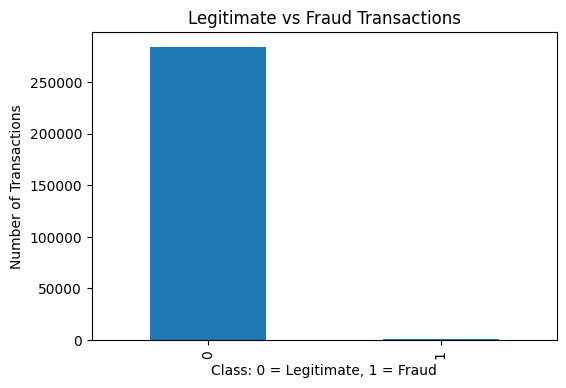

In [2]:
# Class imbalance
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print(class_percent)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Class: 0 = Legitimate, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

Finding:
- The dataset is highly imbalanced. Out of 284,807 transactions, only 492 are fraudulent, representing approximately 0.17% of all transactions. This means accuracy alone is not a reliable metric for this project.

In [3]:
# Transaction amount analysis
df.groupby("Class")["Amount"].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


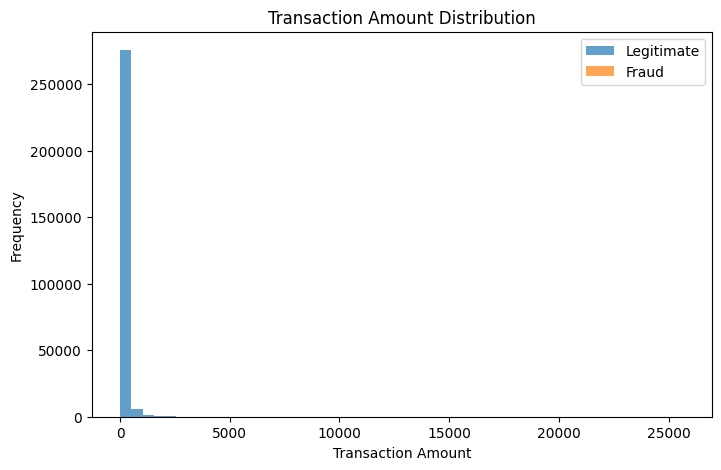

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.7, label="Legitimate")
plt.hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Finding
- Fraudulent transactions have a higher average transaction amount than legitimate transactions. However, many fraud cases also occur at low transaction values, meaning fraud detection should not rely only on transaction amount.

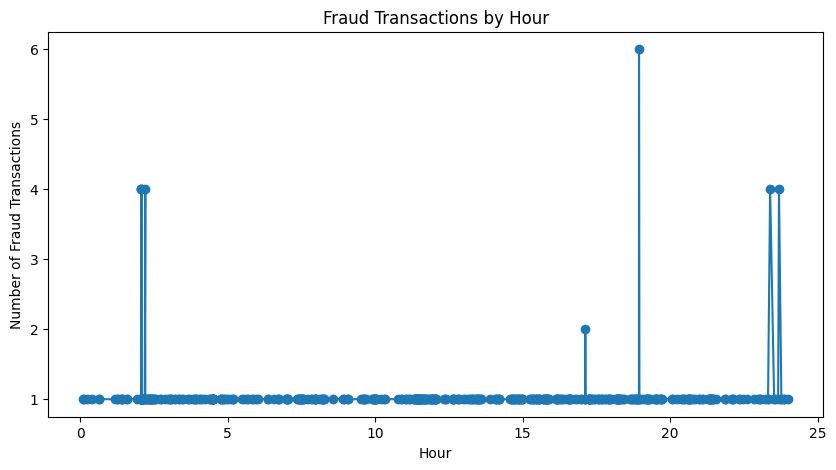

In [5]:
# Time-based fraud pattern
df["Hour"] = (df["Time"] / 3600) % 24

fraud_by_hour = df[df["Class"] == 1].groupby("Hour").size()
legit_by_hour = df[df["Class"] == 0].groupby("Hour").size()

plt.figure(figsize=(10,5))
fraud_by_hour.plot(kind="line", marker="o")
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Fraud Transactions")
plt.show()

Finding
- Fraud transactions vary across the day. Time-based analysis can support fraud monitoring by identifying periods where suspicious activity increases.

In [6]:
# Correlation analysis
correlations = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
correlations

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017082
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

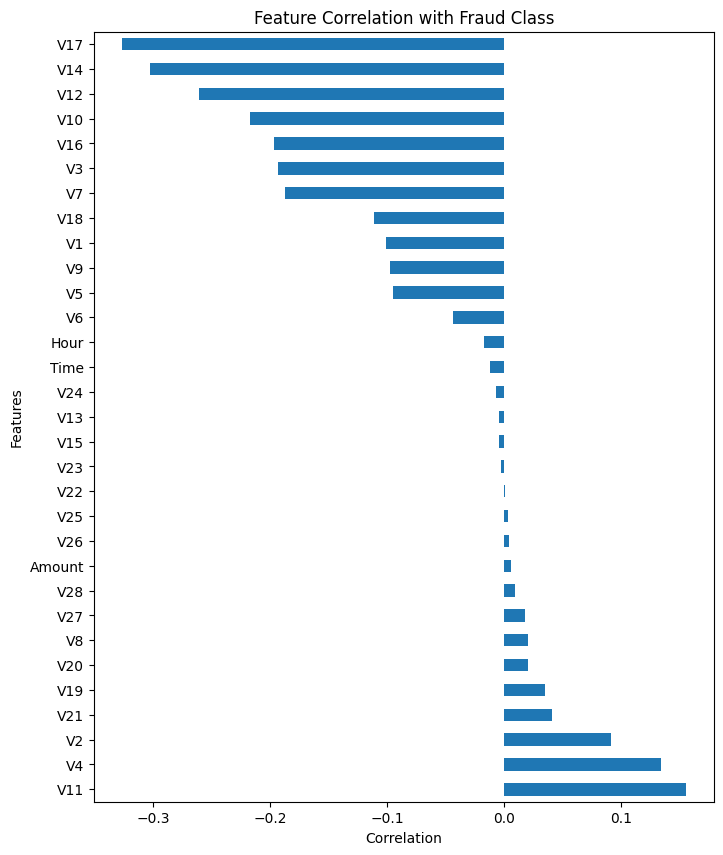

In [7]:
plt.figure(figsize=(8,10))
correlations.drop("Class").plot(kind="barh")
plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

Finding
- Some anonymised PCA features show stronger relationships with the fraud class than others. These features may be useful predictors during model training.

<Figure size 600x400 with 0 Axes>

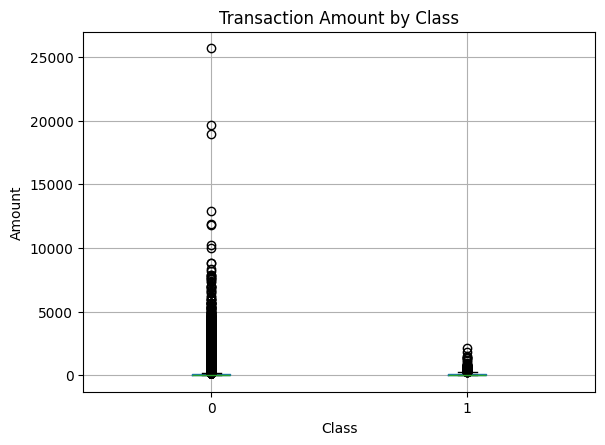

In [8]:
# Compare fraud and legitimate transaction amounts
plt.figure(figsize=(6,4))
df.boxplot(column="Amount", by="Class")
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

In [9]:
# Save cleaned EDA dataset
df.to_csv("../data/processed/creditcard_with_hour.csv", index=False)